# Student Health Risk Prediction

## Research Questions

### Objective

This notebook aims to answer several research questions related to students' lifestyle and health conditions using exploratory data analysis (EDA).

Instead of focusing on data quality or preprocessing, this notebook investigates meaningful relationships between variables and extracts insights that may support feature engineering and predictive modeling.

### Research Questions

The analysis focuses on the following questions:

1. How is students' sleep duration distributed, and what is a typical night's sleep?

2. Do students with higher stress levels tend to sleep less?

3. Is sleep quality associated with resting heart rate?

4. Which diet type is associated with higher levels of physical activity?

5. Does longer exercise duration lead to higher calorie expenditure?

6. Are smoking and alcohol consumption associated with overall health condition?

7. Which health indicators tend to change together, and which appear to be independent?

### Workflow

For each research question, the following steps will be performed:

- Formulate the research question
- Prepare the required data
- Visualize the data
- Interpret the results
- Draw a conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
pd.set_option("display.max_columns", None)

In [2]:
train = pd.read_csv("../data/train.csv", index_col="id")
test = pd.read_csv("../data/test.csv", index_col="id")

### Question 1: How is students' sleep duration distributed, and what is a typical night's sleep

#### why is this question import?
Sleep duration is one of the most important indicators of students' health and lifestyle.

Understanding its distribution provides a general overview of sleeping habits before investigating its relationship with other health indicators.

In [3]:
# data preparation
sleep = train[["sleep_duration"]].dropna()
sleep.head()

,sleep_duration
id,
0,5.22
1,5.53
2,5.29
3,4.70
4,7.23


In [4]:
# Statistical Sumary
sleep.describe()

,sleep_duration
count,614089.000000
mean,6.992597
std,1.215407
min,3.000000
25%,6.160000
50%,6.990000
75%,7.810000
max,10.000000


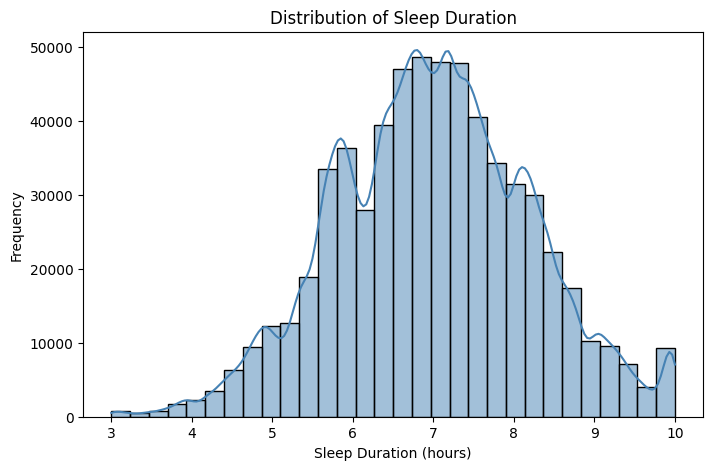

In [5]:
# Visualization
plt.figure(figsize=(8,5))

sns.histplot(
    data=sleep,
    x="sleep_duration",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Frequency")
plt.title("Distribution of Sleep Duration")

plt.show()

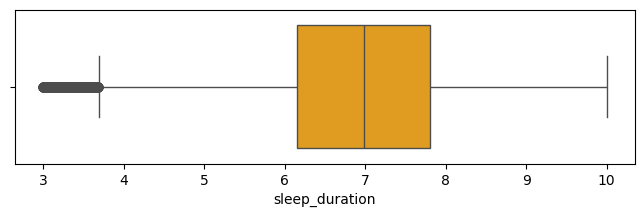

In [6]:
plt.figure(figsize=(8,2))
sns.boxplot(
    data=sleep,
    x="sleep_duration",
    color="orange"
)
plt.show()

#### Conclusion

Students sleep an average of approximately **7.0 hours** per night, with a median sleep duration close to **7.0 hours**.

The distribution is approximately symmetric, indicating that 7 hours represents a typical sleep duration for most students. Only a small proportion of students exhibit unusually short or unusually long sleep durations.

### Question 2: Do students with higher stress levels tend to sleep less?

In [7]:
df=train[
    ["stress_level","sleep_duration"]
].dropna()

In [8]:
df.groupby(
    "stress_level"
)["sleep_duration"].mean()

stress_level
high      6.840951
low       7.075760
medium    7.043105
Name: sleep_duration, dtype: float64

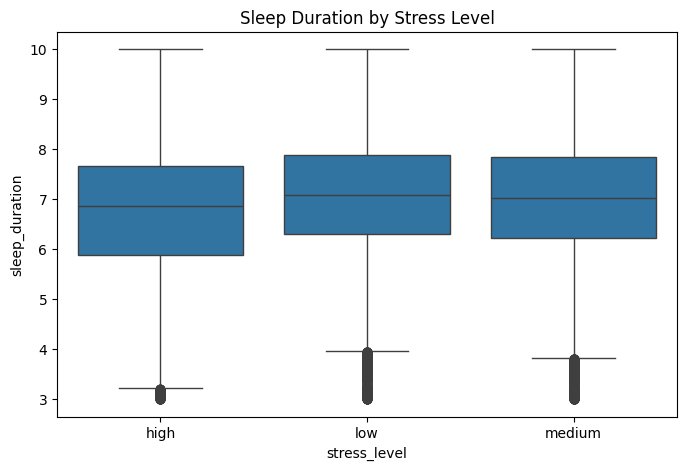

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="stress_level",
    y="sleep_duration"
)
plt.title("Sleep Duration by Stress Level")
plt.show()

#### Observation

- The median sleep duration is approximately 7 hours across all stress levels.
- The distributions of sleep duration are highly similar among the low, medium, and high stress groups.
- All groups contain a small number of students with unusually short sleep durations.
- No substantial differences in sleep duration are visually apparent between stress levels.

In [10]:
df.groupby("stress_level")["sleep_duration"].agg(["count","mean","median","std"])

,count,mean,median,std
stress_level,,,,
high,158217,6.840951,6.87,1.252967
low,149089,7.075760,7.08,1.191616
medium,232985,7.043105,7.02,1.196048


Students in the high stress group sleep slightly less on average; however, the difference is small and the distributions largely overlap.

#### Conclusion

Based on the boxplot, there is no clear visual evidence that students with higher stress levels sleep less than those with lower stress levels.

The sleep duration distributions are very similar across all stress groups. Further statistical analysis would be required to determine whether any observed differences are statistically significant.

### Question 3: is sleep quality associated with resting heart rate?

In [13]:
# data
df_q3=train[["sleep_quality","heart_rate"]].dropna()
df_q3.head()

,sleep_quality,heart_rate
id,,
0,average,70.6
1,average,71.3
2,poor,75.4
3,average,77.2
4,average,73.4


In [ ]:
# statistical sumary
df_q3.groupby("sleep_quality")["heart_rate"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
sleep_quality,,,,,,
average,211539,75.12,75.1,8.19,50.0,107.7
good,203329,75.09,75.0,8.18,50.0,103.8
poor,209704,75.12,75.1,8.14,50.0,104.4


C:\Users\thach\AppData\Local\Temp\ipykernel_24032\780935640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


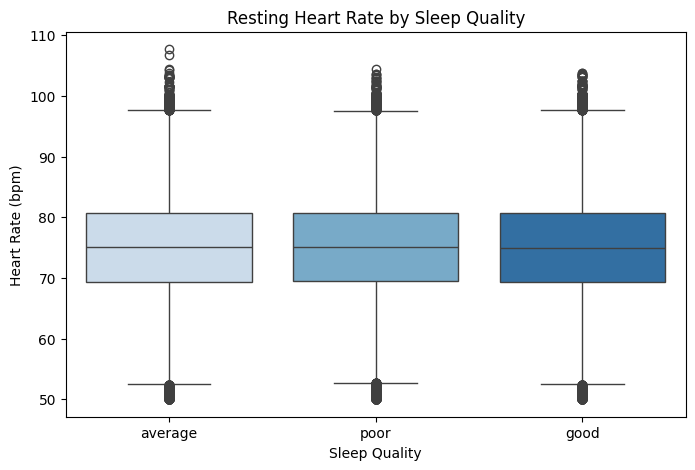

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_q3,
    x="sleep_quality",
    y="heart_rate",
    palette="Blues"
)

plt.title("Resting Heart Rate by Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Heart Rate (bpm)")

plt.show()

#### observation

The median resting heart rate is approximately 75 bpm across all sleep quality categories (average, poor, good).

The distributions (IQR and whiskers) of resting heart rate are nearly identical among all three sleep quality groups.

All groups exhibit outliers at both the lower end (~50–52 bpm) and higher end (>98 bpm).

No substantial visual differences in resting heart rate are apparent between different sleep quality levels.

#### Conclusion

Based on the boxplot, there is no clear visual evidence that sleep quality is associated with resting heart rate.

The heart rate distributions are almost identical across all sleep quality groups, suggesting that resting heart rate alone may not vary significantly with subjective sleep quality in this dataset

### Question 4: Which diet types are associated with the most physical movement?

In [18]:
df_q4 = train[["diet_type", "exercise_duration"]].dropna()

In [19]:
# statistical sumary
df_q4.groupby("diet_type")["exercise_duration"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
diet_type,,,,,,
balanced,224651,38.88,39.5,14.69,0.0,90.1
non-veg,222574,38.67,39.3,14.80,0.0,99.8
veg,229133,38.70,39.4,14.73,0.0,91.6


C:\Users\thach\AppData\Local\Temp\ipykernel_24032\898702353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


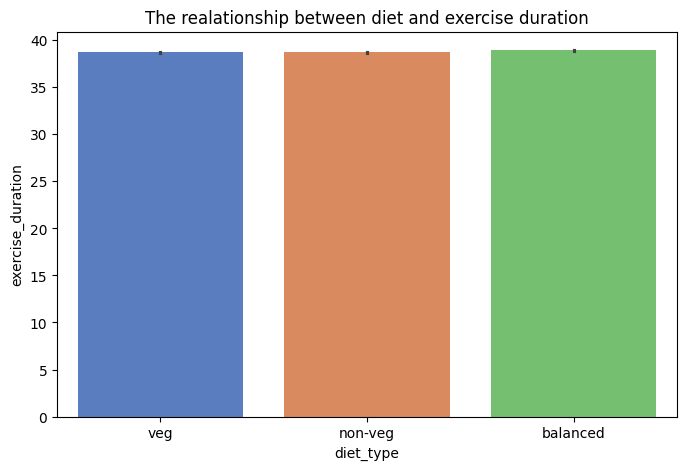

In [21]:
# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_q4,
    x= "diet_type",
    y="exercise_duration",

    palette="muted"
)

plt.title("The realationship between diet and exercise duration")
plt.xlabel("diet_type")
plt.ylabel("exercise_duration")

plt.show()

#### Observation

The average exercise duration across all three diet types (veg, non-veg, and balanced) is nearly identical, hovering around 38.5–39 minutes.

The balanced diet group shows a slightly higher mean exercise duration compared to the other two groups, but the difference is extremely minimal.

The black error bars (confidence intervals) on top of each bar are very small and overlap significantly, indicating high precision and minimal variance between the groups.

#### Conclusion

A balanced diet is most strongly associated with physical activity (although the differences between these three diets are small and almost negligible).

